# YogAI — Mountain Pose Experiment
**Comparative ML Study: Logistic Regression vs SVC vs KNN vs XGBoost**

This notebook runs the full hyperparameter search, cross-validation, and
inference latency benchmark for the **Mountain Pose** classifier.

All artifacts (pipeline, label encoder, class map, metadata) are saved to
the working directory so they can be loaded directly during real-video inference.

---
### Notebook Structure
1. Environment setup & imports  
2. Configuration — Mountain Pose  
3. Data loading & validation  
4. Exploratory checks (class balance, feature stats)  
5. Experiment loop — all 4 models  
6. Results & benchmark table  
7. Artifact verification  
8. Inference smoke-test (load saved artifacts & predict one sample)


## 1. Environment Setup

In [1]:
# Install dependencies if running for the first time
# Comment out after first run
import subprocess, sys

packages = ["scikit-learn", "xgboost", "pandas", "numpy", "matplotlib",
            "seaborn", "joblib", "pyyaml"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [2]:
import sys
import json
import time
import math
import warnings
import logging
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, GroupKFold,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

#  Add src/ to path so we can import project modules 
NOTEBOOK_DIR = Path(".").resolve()

# Go up from src/models/training -> project root
PROJECT_ROOT = NOTEBOOK_DIR.parents[2]

SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR))

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)

print(f"Working directory : {NOTEBOOK_DIR}")
print(f"src/ on path      : {SRC_DIR.exists()}")

Working directory : D:\YogAi_Models_Refactor\src\models\training
src/ on path      : True


## 2. Configuration — Mountain Pose

In [3]:
#  Pose identity 
POSE_NAME = "mountain_pose"

# Path to the mountain pose CSV
# Update this to your actual file path if it differs
CSV_PATH = Path("../../../data/processed/engineered_features/mountain_pose/mountain_pose_features.csv")


#  Feature columns (must match CSV headers exactly) 
FEATURE_COLUMNS = [
    "left_torso_hip_angle",
    "right_torso_hip_angle",
    "left_shoulder_arm_angle",
    "right_shoulder_arm_angle",
    "neck_tilt_angle",
    "feet_distance_normalized",
    "ear_shoulder_lateral_delta",
    "plumb_line_alignment",
]

LABEL_COLUMN    = "label"
SOURCE_ID_COL   = "source_id"        # same value for all frames from one video
FRAME_NUMBER_COL = "frame_number"

#  Cross-validation settings 
CV_CONFIG = {
    "n_splits"   : 5,
    "random_seed": 42,
    "scoring"    : "f1_weighted",
    "n_jobs"     : -1,
}

#  Hyperparameter grids ─
# KNN NOTE: n_neighbors must never exceed floor(sqrt(n_training_samples)).
# A runtime warning is raised below if any value violates this.
HYPERPARAMETER_GRIDS = {
    "logistic_regression": {
        "classifier__C"       : [0.01, 0.1, 1.0, 10.0, 100.0],
        "classifier__penalty" : ["l2"],
        "classifier__solver"  : ["lbfgs"],
        "classifier__max_iter": [1000],
    },
    "svc": {
        "classifier__C"     : [0.1, 1.0, 10.0, 100.0],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma" : ["scale", "auto"],
    },
    "knn": {
        "classifier__n_neighbors": [3, 5, 7, 11, 15],
        "classifier__weights"    : ["uniform", "distance"],
        "classifier__metric"     : ["euclidean", "manhattan"],
    },
    "xgboost": {
        "classifier__n_estimators"    : [100, 200, 300],
        "classifier__max_depth"       : [3, 5, 7],
        "classifier__learning_rate"   : [0.01, 0.05, 0.1, 0.2],
        "classifier__subsample"       : [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5],
    },
}

XGBOOST_RANDOM_SEARCH_ITER = 30
LATENCY_WARMUP_CALLS       = 10
LATENCY_TRIAL_CALLS        = 500

print("Configuration loaded.")
print(f"Pose            : {POSE_NAME}")
print(f"Features        : {FEATURE_COLUMNS}")
print(f"CSV path        : {CSV_PATH}")
print(f"CSV exists      : {CSV_PATH.exists()}")

Configuration loaded.
Pose            : mountain_pose
Features        : ['left_torso_hip_angle', 'right_torso_hip_angle', 'left_shoulder_arm_angle', 'right_shoulder_arm_angle', 'neck_tilt_angle', 'feet_distance_normalized', 'ear_shoulder_lateral_delta', 'plumb_line_alignment']
CSV path        : ..\..\..\data\processed\engineered_features\mountain_pose\mountain_pose_features.csv
CSV exists      : True


In [20]:
#  Output folder structure 
# Root is created one level above the notebook file (.. folder)
# Structure:
#   ../mountain_pose_files/
#       models/       — .joblib pipeline and label encoder files
#       metadata/     — .json class maps and metadata files
#       results/      — experiment summary CSV
#       images/       — confusion matrix and latency chart PNGs

NOTEBOOK_DIR  = Path(".").resolve()
OUTPUT_ROOT = NOTEBOOK_DIR.parent / "saved_files" / f"{POSE_NAME}_files"

DIR_MODELS    = OUTPUT_ROOT / "models"
DIR_METADATA  = OUTPUT_ROOT / "metadata"
DIR_RESULTS   = OUTPUT_ROOT / "results"
DIR_IMAGES    = OUTPUT_ROOT / "images"

for folder in [DIR_MODELS, DIR_METADATA, DIR_RESULTS, DIR_IMAGES]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Output root : {OUTPUT_ROOT}")
print(f"  models/   : {DIR_MODELS}")
print(f"  metadata/ : {DIR_METADATA}")
print(f"  results/  : {DIR_RESULTS}")
print(f"  images/   : {DIR_IMAGES}")

Output root : D:\YogAi_Models_Refactor\src\models\saved_files\mountain_pose_files
  models/   : D:\YogAi_Models_Refactor\src\models\saved_files\mountain_pose_files\models
  metadata/ : D:\YogAi_Models_Refactor\src\models\saved_files\mountain_pose_files\metadata
  results/  : D:\YogAi_Models_Refactor\src\models\saved_files\mountain_pose_files\results
  images/   : D:\YogAi_Models_Refactor\src\models\saved_files\mountain_pose_files\images


## 3. Data Loading & Validation

In [4]:
#  Load CSV 
assert CSV_PATH.exists(), (
    f"CSV not found at '{CSV_PATH}'. "
    f"Update CSV_PATH in the Configuration cell above."
)

df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (4640, 11)


,source_id,label,frame_number,left_torso_hip_angle,right_torso_hip_angle,left_shoulder_arm_angle,right_shoulder_arm_angle,neck_tilt_angle,feet_distance_normalized,ear_shoulder_lateral_delta,plumb_line_alignment
0,arms_not_dropped_1.mp4,arms_not_dropped,8,171.623107,142.059474,76.173364,75.223764,153.660118,1.453785,0.765044,0.652781
1,arms_not_dropped_1.mp4,arms_not_dropped,16,157.589018,175.779878,71.493351,71.652851,149.690935,1.028959,0.750571,0.671803
2,arms_not_dropped_1.mp4,arms_not_dropped,24,157.861555,173.765482,72.147736,70.302284,149.249455,0.856278,0.499625,0.698459
3,arms_not_dropped_1.mp4,arms_not_dropped,32,161.416415,164.771271,75.027724,74.770948,150.811223,0.501705,0.317836,0.687558
4,arms_not_dropped_1.mp4,arms_not_dropped,40,155.048219,168.451045,73.911511,74.359778,149.832471,0.585148,0.324346,0.653127


In [6]:
#  Validate required columns are present 
required_cols = FEATURE_COLUMNS + [LABEL_COLUMN, SOURCE_ID_COL]
missing_cols  = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(
        f"The following required columns are missing from the CSV: {missing_cols}\n"
        f"Available columns: {list(df.columns)}"
    )

print("All required columns present.")
print(f"\nColumn dtypes:")
print(df[required_cols].dtypes)

All required columns present.

Column dtypes:
left_torso_hip_angle          float64
right_torso_hip_angle         float64
left_shoulder_arm_angle       float64
right_shoulder_arm_angle      float64
neck_tilt_angle               float64
feet_distance_normalized      float64
ear_shoulder_lateral_delta    float64
plumb_line_alignment          float64
label                             str
source_id                         str
dtype: object


In [7]:
#  Check for nulls 
null_counts = df[required_cols].isnull().sum()
null_counts = null_counts[null_counts > 0]

if not null_counts.empty:
    print("WARNING: Null values detected:")
    print(null_counts)
    print("\nDropping rows with nulls...")
    df = df.dropna(subset=required_cols)
    print(f"Shape after dropping nulls: {df.shape}")
else:
    print("No null values. Dataset is clean.")

No null values. Dataset is clean.


In [8]:
#  Encode string labels to integers 
# LabelEncoder is fitted here on the full label set so all classes are known.
# The fitted encoder is saved as an artifact — inference must load and use
# this exact encoder to decode predictions back to strings.

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(df[LABEL_COLUMN].str.lower().str.strip())

class_map = {idx: cls for idx, cls in enumerate(label_encoder.classes_)}
print("Label encoding:")
for k, v in class_map.items():
    count = (y_encoded == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples, {count/len(y_encoded)*100:.1f}%)")

Label encoding:
  0 -> 'arms_not_dropped'  (900 samples, 19.4%)
  1 -> 'bent_forward'  (900 samples, 19.4%)
  2 -> 'correct'  (1040 samples, 22.4%)
  3 -> 'tilted_head'  (900 samples, 19.4%)
  4 -> 'wide_stance'  (900 samples, 19.4%)


**Label encoding**:
  - 0 -> 'arms_not_dropped'  (900 samples, 19.4%)
  - 1 -> 'bent_forward'  (900 samples, 19.4%)
  - 2 -> 'correct'  (1040 samples, 22.4%)
  - 3 -> 'tilted_head'  (900 samples, 19.4%)
  - 4 -> 'wide_stance'  (900 samples, 19.4%)

In [9]:
#  Extract X, y, groups 
X      = df[FEATURE_COLUMNS].values
y      = y_encoded
groups = df[SOURCE_ID_COL].values   # one group = one video source

n_unique_sources = len(np.unique(groups))
n_samples        = len(X)

print(f"\nDataset summary")
print(f"  Samples         : {n_samples}")
print(f"  Features        : {X.shape[1]}")
print(f"  Classes         : {len(class_map)}")
print(f"  Unique source_ids: {n_unique_sources}")
print(f"  (each source_id will stay entirely in train OR test — never split across both)")


Dataset summary
  Samples         : 4640
  Features        : 8
  Classes         : 5
  Unique source_ids: 45
  (each source_id will stay entirely in train OR test — never split across both)


In [10]:
#  Experiment toggle — exclude bent_forward ─
# HYPOTHESIS: bent_forward and correct share overlapping feature distributions,
# causing the model to conflate the two classes. This experiment tests whether
# removing bent_forward improves correct's recall and overall model performance.
#
# Set to True to run the 4-class experiment (excluding bent_forward)
# Set to False to run the full 5-class experiment (default)

EXCLUDE_BENT_FORWARD = True   # <-- toggle here

#  Apply filter ─
if EXCLUDE_BENT_FORWARD:
    bent_forward_encoded = label_encoder.transform(["bent_forward"])[0]
    keep_mask = y != bent_forward_encoded

    X      = X[keep_mask]
    y      = y[keep_mask]
    groups = groups[keep_mask]

    # Re-encode labels to consecutive integers (0,1,2,3) after dropping a class
    # — this prevents XGBoost from seeing a gap in class indices (0,1,3,4)
    # which would cause silent errors in num_class detection
    remaining_classes  = sorted(np.unique(y))
    remap              = {old: new for new, old in enumerate(remaining_classes)}
    y                  = np.array([remap[lbl] for lbl in y])

    # Rebuild class_map and refit label_encoder on remaining classes only
    remaining_names    = label_encoder.inverse_transform(remaining_classes)
    label_encoder      = LabelEncoder()
    label_encoder.fit(remaining_names)
    class_map          = {i: name for i, name in enumerate(remaining_names)}

    experiment_tag = "4class_no_bent_forward"
    print("EXCLUDED: bent_forward")
else:
    experiment_tag = "5class_full"
    print("Running full 5-class experiment.")

print(f"\nExperiment tag : {experiment_tag}")
print(f"Remaining classes ({len(class_map)}):")
for k, v in class_map.items():
    count = (y == k).sum()
    print(f"  {k} -> '{v}'  ({count} samples)")

EXCLUDED: bent_forward

Experiment tag : 4class_no_bent_forward
Remaining classes (4):
  0 -> 'arms_not_dropped'  (900 samples)
  1 -> 'correct'  (1040 samples)
  2 -> 'tilted_head'  (900 samples)
  3 -> 'wide_stance'  (900 samples)


## 4. Exploratory Checks

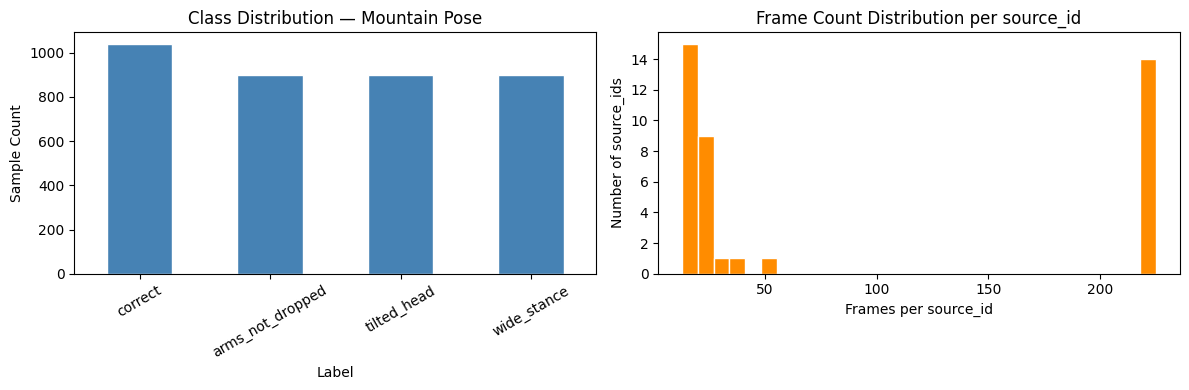

In [11]:
#  Class distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_strings = label_encoder.inverse_transform(y)
pd.Series(label_strings).value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Class Distribution — Mountain Pose")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=30)

# Samples per source_id (frame count per video)
pd.Series(groups).value_counts().plot(
    kind="hist", bins=30, ax=axes[1], color="darkorange", edgecolor="white"
)
axes[1].set_title("Frame Count Distribution per source_id")
axes[1].set_xlabel("Frames per source_id")
axes[1].set_ylabel("Number of source_ids")

plt.tight_layout()
plt.show()

In [12]:
#  Feature statistics 
feature_df = pd.DataFrame(X, columns=FEATURE_COLUMNS)
feature_df.describe().round(4)

,left_torso_hip_angle,right_torso_hip_angle,left_shoulder_arm_angle,right_shoulder_arm_angle,neck_tilt_angle,feet_distance_normalized,ear_shoulder_lateral_delta,plumb_line_alignment
count,3740.0000,3740.0000,3740.0000,3740.0000,3740.0000,3740.0000,3740.0000,3740.0000
mean,155.9182,151.9710,55.4758,51.4918,152.7823,0.8372,6.1827,0.5362
std,9.2816,10.7174,17.5897,16.0923,6.5860,0.4826,7.2147,0.1313
min,108.9629,92.9324,23.1283,17.9970,114.8383,0.0751,0.0033,0.1866
25%,150.2975,146.1449,44.6240,41.8344,149.1926,0.5003,1.4659,0.4432
50%,155.2276,151.9658,51.2285,47.9990,154.1867,0.6456,3.0973,0.5358
75%,162.3553,158.5133,58.4746,55.4699,157.4746,1.1249,7.1843,0.6243
max,176.6823,176.5355,162.1911,155.7694,166.3974,2.9916,127.7171,1.0929


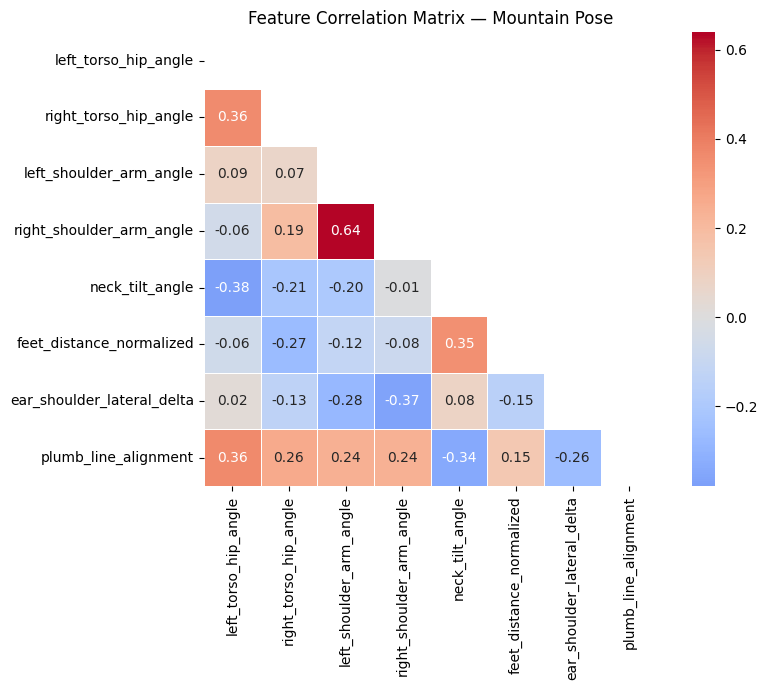

In [13]:
#  Feature correlation heatmap 
fig, ax = plt.subplots(figsize=(9, 7))
corr = feature_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    linewidths=0.5, square=True,
)
ax.set_title("Feature Correlation Matrix — Mountain Pose")
plt.tight_layout()
plt.show()

## 5. Experiment Helpers

In [14]:
def build_pipeline(model_name: str) -> Pipeline:
    """
    Return an unfitted sklearn Pipeline: StandardScaler -> estimator.
    Must be unfitted when passed to GridSearchCV to prevent leakage.
    """
    seed = CV_CONFIG["random_seed"]

    estimators = {
        "logistic_regression": LogisticRegression(random_state=seed, max_iter=1000),
        "svc"                : SVC(random_state=seed, probability=True),
        "knn"                : KNeighborsClassifier(n_neighbors=5),
        "xgboost"            : XGBClassifier(
                                   random_state=seed,
                                   verbosity=0,
                                   eval_metric="mlogloss",
                               ),
    }

    if model_name not in estimators:
        raise ValueError(f"Unknown model '{model_name}'. Choose from {list(estimators)}")

    return Pipeline([
        ("scaler"    , StandardScaler()),
        ("classifier", estimators[model_name]),
    ])


def check_knn_neighbor_cap(n_neighbors_grid: list, n_training_samples: int) -> None:
    """Warn if any n_neighbors value exceeds floor(sqrt(n_training_samples))."""
    ceiling    = math.floor(math.sqrt(n_training_samples))
    oversized  = [k for k in n_neighbors_grid if k > ceiling]
    if oversized:
        warnings.warn(
            f"KNN grid has n_neighbors values {oversized} exceeding the "
            f"recommended ceiling floor(sqrt({n_training_samples})) = {ceiling}. "
            f"Consider trimming the grid.",
            UserWarning, stacklevel=2,
        )


def measure_inference_latency(
    pipeline, X_probe: np.ndarray,
    n_warmup: int = LATENCY_WARMUP_CALLS,
    n_trials: int = LATENCY_TRIAL_CALLS,
) -> dict:
    """
    Measure per-sample prediction latency.
    Warm-up calls are discarded to eliminate cold-start bias.
    p95/p99 are reported because real-time systems are bounded by tail latency.
    """
    for _ in range(n_warmup):
        pipeline.predict(X_probe)

    latencies_ms = np.empty(n_trials)
    for i in range(n_trials):
        t0 = time.perf_counter()
        pipeline.predict(X_probe)
        latencies_ms[i] = (time.perf_counter() - t0) * 1000.0

    return {
        "mean_ms"        : round(float(np.mean(latencies_ms)), 4),
        "std_ms"         : round(float(np.std(latencies_ms)), 4),
        "p95_ms"         : round(float(np.percentile(latencies_ms, 95)), 4),
        "p99_ms"         : round(float(np.percentile(latencies_ms, 99)), 4),
        "implied_max_fps": round(1000.0 / float(np.mean(latencies_ms)), 1),
    }

print("Helper functions defined.")

Helper functions defined.


## 6. Train / Test Split

In [15]:
from collections import defaultdict

seed = CV_CONFIG["random_seed"]
rng  = np.random.default_rng(seed)

#  Build a map: source_id -> majority class label ─
# Each source_id belongs to one class (one video = one pose correctness label)
# We take the majority label in case of any noise/mixed frames
source_to_label = {}
for src in np.unique(groups):
    mask = groups == src
    majority_label = int(pd.Series(y[mask]).mode()[0])
    source_to_label[src] = majority_label

#  Group source_ids by their class ─
class_to_sources = defaultdict(list)
for src, lbl in source_to_label.items():
    class_to_sources[lbl].append(src)

print("Source_ids per class:")
for lbl, srcs in sorted(class_to_sources.items()):
    print(f"  {class_map[lbl]}: {len(srcs)} source_ids")

#  Sample 20% of source_ids from EACH class for test ─
test_sources  = set()
train_sources = set()

for lbl, srcs in class_to_sources.items():
    srcs_arr       = np.array(srcs)
    n_test         = max(1, int(len(srcs_arr) * 0.2))
    chosen_test    = set(rng.choice(srcs_arr, size=n_test, replace=False))
    test_sources  |= chosen_test
    train_sources |= (set(srcs_arr) - chosen_test)

#  Apply masks 
test_mask  = np.isin(groups, list(test_sources))
train_mask = ~test_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train    = groups[train_mask]

print(f"\nTrain: {len(X_train)} samples across {len(train_sources)} source_ids")
print(f"Test : {len(X_test)} samples across {len(test_sources)} source_ids")

print("\nTrain class distribution:")
for k, v in class_map.items():
    count = (y_train == k).sum()
    print(f"  {v}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nTest class distribution:")
for k, v in class_map.items():
    count = (y_test == k).sum()
    print(f"  {v}: {count} ({count/len(y_test)*100:.1f}%)")

Source_ids per class:
  arms_not_dropped: 4 source_ids
  correct: 29 source_ids
  tilted_head: 4 source_ids
  wide_stance: 4 source_ids

Train: 2965 samples across 33 source_ids
Test : 775 samples across 8 source_ids

Train class distribution:
  arms_not_dropped: 675 (22.8%)
  correct: 940 (31.7%)
  tilted_head: 675 (22.8%)
  wide_stance: 675 (22.8%)

Test class distribution:
  arms_not_dropped: 225 (29.0%)
  correct: 100 (12.9%)
  tilted_head: 225 (29.0%)
  wide_stance: 225 (29.0%)


In [16]:
#  Class balance assessment ─
train_counts = pd.Series(y_train).value_counts().sort_index()
max_count    = train_counts.max()
min_count    = train_counts.min()
imbalance_ratio = max_count / min_count

print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Assessment: BALANCED — no resampling or class weighting needed.")
    print("Justification: ratio < 1.5, f1_weighted scoring already accounts")
    print("for minor differences in class support.")
elif imbalance_ratio < 3.0:
    print("Assessment: MILDLY IMBALANCED — consider class_weight='balanced'")
    print("for LogisticRegression and SVC.")
else:
    print("Assessment: IMBALANCED — add class_weight='balanced' to LR and SVC,")
    print("and set scale_pos_weight in XGBoost.")

Imbalance ratio (max/min): 1.39
Assessment: BALANCED — no resampling or class weighting needed.
Justification: ratio < 1.5, f1_weighted scoring already accounts
for minor differences in class support.


## 7. Experiment Loop — All 4 Models

In [21]:
# GroupKFold — folds also respect source_id boundaries during CV
n_unique_train_sources = len(np.unique(groups_train))
n_splits_actual        = min(CV_CONFIG["n_splits"], n_unique_train_sources)
cv_strategy            = GroupKFold(n_splits=n_splits_actual)

print(f"CV strategy : GroupKFold with {n_splits_actual} splits")
print(f"Scoring     : {CV_CONFIG['scoring']}")
print()

MODELS        = ["logistic_regression", "svc", "knn", "xgboost"]
all_results   = []
best_pipelines = {}

for model_name in MODELS:
    print(f"{'='*60}")
    print(f"  Running: {model_name.upper().replace('_', ' ')}")
    print(f"{'='*60}")

    # Build unfitted pipeline — scaler must not be fitted before GridSearchCV
    pipeline   = build_pipeline(model_name)
    param_grid = HYPERPARAMETER_GRIDS[model_name]

    # KNN neighbor cap check
    if model_name == "knn":
        check_knn_neighbor_cap(
            param_grid["classifier__n_neighbors"], len(X_train)
        )

    # XGBoost uses RandomizedSearchCV due to larger grid
    if model_name == "xgboost":
        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            n_iter=XGBOOST_RANDOM_SEARCH_ITER,
            scoring=CV_CONFIG["scoring"],
            cv=cv_strategy,
            n_jobs=CV_CONFIG["n_jobs"],
            random_state=seed,
            refit=True,
            verbose=0,
        )
    else:
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring=CV_CONFIG["scoring"],
            cv=cv_strategy,
            n_jobs=CV_CONFIG["n_jobs"],
            refit=True,
            verbose=0,
        )

    search.fit(X_train, y_train, groups=groups_train)

    best_pipeline = search.best_estimator_
    best_pipelines[model_name] = best_pipeline

    # Evaluate on held-out test set
    y_pred        = best_pipeline.predict(X_test)
    clf_dict      = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    clf_str       = classification_report(
                        y_test, y_pred,
                        target_names=list(class_map.values()),
                        zero_division=0,
                    )
    conf_mat      = confusion_matrix(y_test, y_pred)

    # Inference latency
    X_probe       = X_test[0:1]
    latency       = measure_inference_latency(best_pipeline, X_probe)

    result = {
        "model"                    : model_name,
        "best_cv_score"            : round(search.best_score_, 4),
        "test_f1_weighted"         : round(clf_dict["weighted avg"]["f1-score"], 4),
        "test_precision_weighted"  : round(clf_dict["weighted avg"]["precision"], 4),
        "test_recall_weighted"     : round(clf_dict["weighted avg"]["recall"], 4),
        "test_accuracy"            : round(clf_dict["accuracy"], 4),
        "best_params"              : search.best_params_,
        "classification_report_str": clf_str,
        "confusion_matrix"         : conf_mat,
        **latency,
    }
    all_results.append(result)

    #  Print per-model summary 
    print(f"Best CV score  : {result['best_cv_score']}")
    print(f"Best params    : {search.best_params_}")
    print()
    print("Classification Report (test set):")
    print(clf_str)
    print(f"Latency  mean={latency['mean_ms']} ms | "
          f"p95={latency['p95_ms']} ms | "
          f"p99={latency['p99_ms']} ms | "
          f"implied FPS={latency['implied_max_fps']}")

    #  Save artifacts immediately after each model 
    prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"

    joblib.dump(best_pipeline, DIR_MODELS    / f"{prefix}_pipeline.joblib")
    joblib.dump(label_encoder, DIR_MODELS    / f"{prefix}_label_encoder.joblib")

    with open(DIR_METADATA / f"{prefix}_class_map.json", "w") as f:
        json.dump({str(k): v for k, v in class_map.items()}, f, indent=2)

    metadata = {
        "pose"                 : POSE_NAME,
        "experiment_tag"       : experiment_tag,
        "model"                : model_name,
        "feature_columns"      : FEATURE_COLUMNS,
        "n_features"           : len(FEATURE_COLUMNS),
        "best_params"          : search.best_params_,
        "best_cv_score"        : result["best_cv_score"],
        "test_f1_weighted"     : result["test_f1_weighted"],
        "test_accuracy"        : result["test_accuracy"],
        "n_train"              : len(X_train),
        "n_test"               : len(X_test),
        "cv_config"            : CV_CONFIG,
        "class_map"            : {str(k): v for k, v in class_map.items()},
        "latency"              : latency,
        "confusion_matrix"     : conf_mat.tolist(),
        "classification_report": clf_str,
    }

    with open(DIR_METADATA / f"{prefix}_metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Artifacts saved to {OUTPUT_ROOT.name}/")
    print(f"  models/   {prefix}_pipeline.joblib")
    print(f"  models/   {prefix}_label_encoder.joblib")
    print(f"  metadata/ {prefix}_class_map.json")
    print(f"  metadata/ {prefix}_metadata.json")
    print()
print("All Experiment Completed.")

CV strategy : GroupKFold with 5 splits
Scoring     : f1_weighted

  Running: LOGISTIC REGRESSION


d:\YogAi_Models_Refactor\venv_yogai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best CV score  : 0.7862
Best params    : {'classifier__C': 1.0, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Classification Report (test set):
                  precision    recall  f1-score   support

arms_not_dropped       0.91      0.94      0.93       225
         correct       0.93      1.00      0.96       100
     tilted_head       1.00      0.98      0.99       225
     wide_stance       0.95      0.90      0.92       225

        accuracy                           0.95       775
       macro avg       0.95      0.96      0.95       775
    weighted avg       0.95      0.95      0.95       775

Latency  mean=0.1614 ms | p95=0.281 ms | p99=0.5164 ms | implied FPS=6196.6
Artifacts saved to mountain_pose_files/
  models/   mountain_pose_4class_no_bent_forward_logistic_regression_pipeline.joblib
  models/   mountain_pose_4class_no_bent_forward_logistic_regression_label_encoder.joblib
  metadata/ mountain_pose_4class_no_bent_forward_logi

## 8. Results & Benchmark Table

In [22]:
#  Flat benchmark table ─
benchmark_cols = [
    "model", "best_cv_score",
    "test_f1_weighted", "test_precision_weighted",
    "test_recall_weighted", "test_accuracy",
    "mean_ms", "p95_ms", "p99_ms", "implied_max_fps",
]

results_df = pd.DataFrame(all_results)[benchmark_cols]
results_df = results_df.sort_values("test_f1_weighted", ascending=False).reset_index(drop=True)

csv_path = DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"Results saved to {OUTPUT_ROOT.name}/results/{csv_path.name}")
print()
results_df

Results saved to mountain_pose_files/results/mountain_pose_4class_no_bent_forward_experiment_results.csv



,model,best_cv_score,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_accuracy,mean_ms,p95_ms,p99_ms,implied_max_fps
0,logistic_regression,0.7862,0.9484,0.9494,0.9484,0.9484,0.1614,0.2810,0.5164,6196.6
1,knn,0.8471,0.9398,0.9437,0.9394,0.9394,1.4615,2.4056,3.2924,684.2
2,xgboost,0.8209,0.9286,0.9358,0.9265,0.9265,0.8770,1.1527,1.6330,1140.3
3,svc,0.8604,0.9242,0.9400,0.9200,0.9200,0.3403,0.6866,1.0430,2938.7


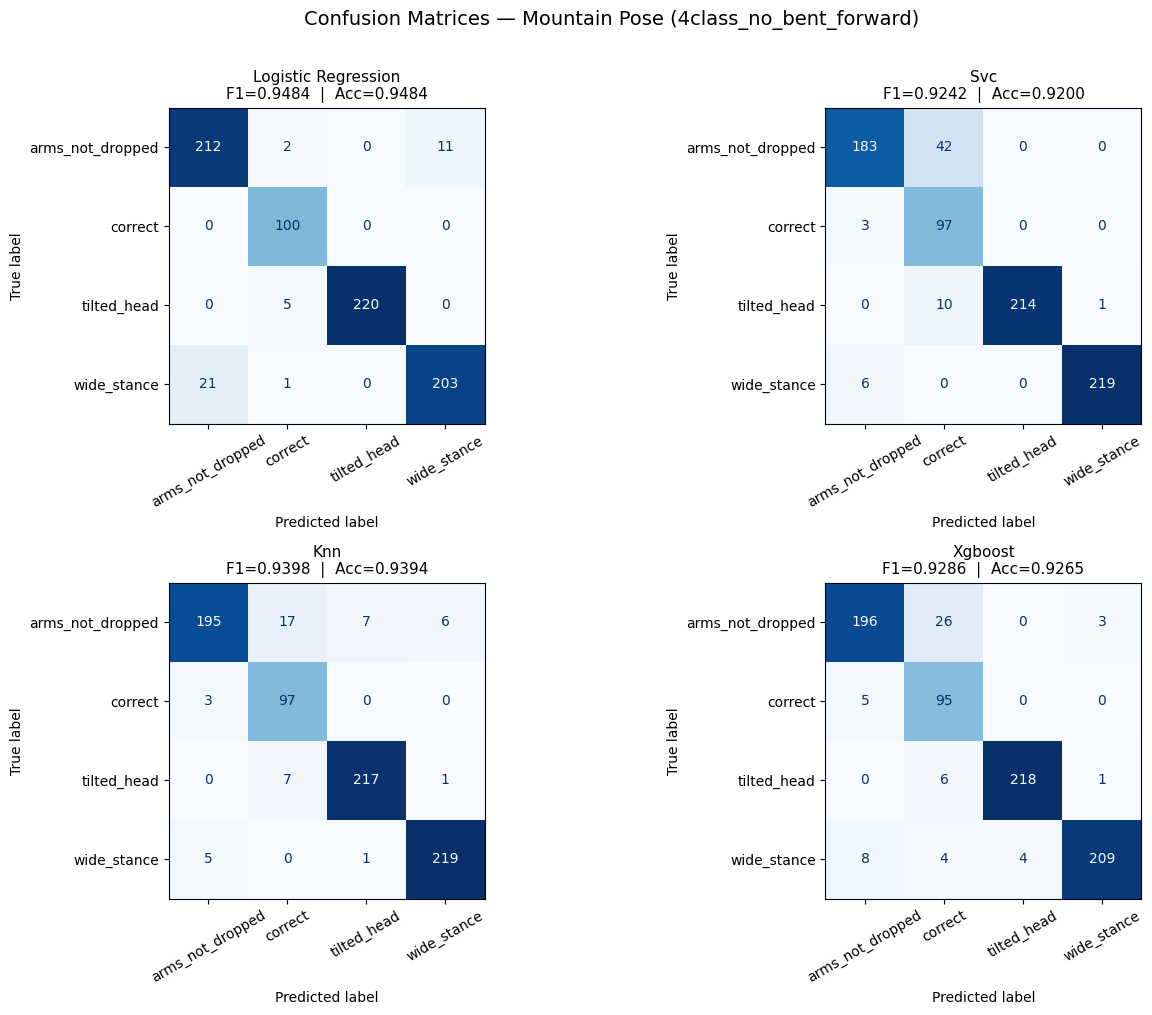

Saved -> mountain_pose_files/images/mountain_pose_4class_no_bent_forward_confusion_matrices.png


In [23]:
#  Confusion matrices — all 4 models ─
fig, axes   = plt.subplots(2, 2, figsize=(14, 10))
axes        = axes.flatten()
class_names = list(class_map.values())

for i, result in enumerate(all_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result["confusion_matrix"],
        display_labels=class_names,
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(
        f"{result['model'].replace('_', ' ').title()}\n"
        f"F1={result['test_f1_weighted']:.4f}  |  "
        f"Acc={result['test_accuracy']:.4f}",
        fontsize=11,
    )
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle(
    f"Confusion Matrices — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})",
    fontsize=14, y=1.01,
)
plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

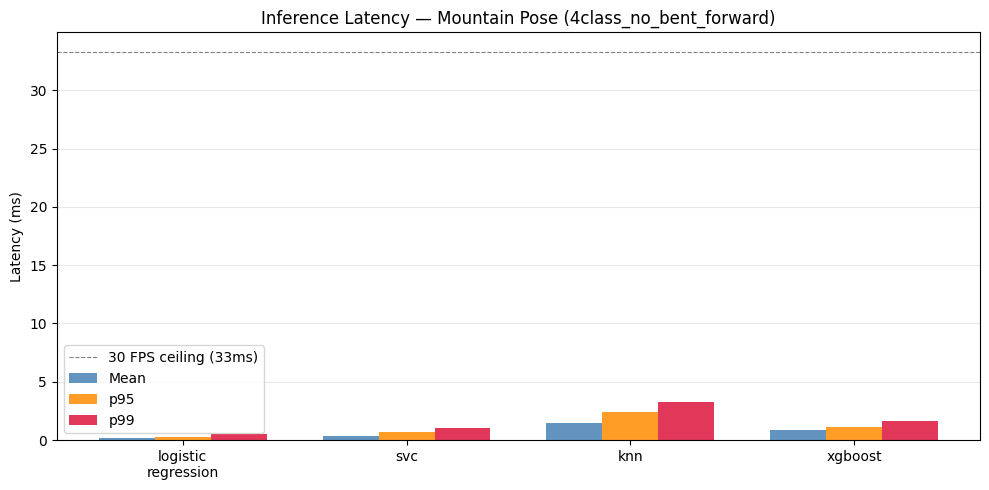

Saved -> mountain_pose_files/images/mountain_pose_4class_no_bent_forward_latency_comparison.png


In [24]:
#  Latency comparison bar chart ─
fig, ax = plt.subplots(figsize=(10, 5))

model_labels = [r["model"].replace("_", "\n") for r in all_results]
mean_vals    = [r["mean_ms"] for r in all_results]
p95_vals     = [r["p95_ms"]  for r in all_results]
p99_vals     = [r["p99_ms"]  for r in all_results]

x     = np.arange(len(model_labels))
width = 0.25

ax.bar(x - width, mean_vals, width, label="Mean", color="steelblue",  alpha=0.85)
ax.bar(x,         p95_vals,  width, label="p95",  color="darkorange", alpha=0.85)
ax.bar(x + width, p99_vals,  width, label="p99",  color="crimson",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Latency (ms)")
ax.set_title(
    f"Inference Latency — {POSE_NAME.replace('_', ' ').title()} ({experiment_tag})"
)
ax.axhline(y=33.3, color="gray", linestyle="--", linewidth=0.8, label="30 FPS ceiling (33ms)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

img_path = DIR_IMAGES / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png"
plt.savefig(img_path, dpi=150)
plt.show()
print(f"Saved -> {OUTPUT_ROOT.name}/images/{img_path.name}")

## 9. Artifact Verification

In [25]:
#  Confirm all expected artifacts were written to disk ─
expected_files = []
for model_name in MODELS:
    prefix = f"{POSE_NAME}_{experiment_tag}_{model_name}"
    expected_files += [
        (DIR_MODELS    / f"{prefix}_pipeline.joblib"),
        (DIR_MODELS    / f"{prefix}_label_encoder.joblib"),
        (DIR_METADATA  / f"{prefix}_class_map.json"),
        (DIR_METADATA  / f"{prefix}_metadata.json"),
    ]

expected_files += [
    DIR_RESULTS / f"{POSE_NAME}_{experiment_tag}_experiment_results.csv",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_confusion_matrices.png",
    DIR_IMAGES  / f"{POSE_NAME}_{experiment_tag}_latency_comparison.png",
]

all_ok = True
for fpath in expected_files:
    exists  = fpath.exists()
    status  = "OK"      if exists else "MISSING"
    folder  = fpath.parent.name
    if not exists:
        all_ok = False
    print(f"  [{status}]  {folder}/{fpath.name}")

print()
print("All artifacts present." if all_ok else "WARNING: Some artifacts are missing.")

  [OK]  models/mountain_pose_4class_no_bent_forward_logistic_regression_pipeline.joblib
  [OK]  models/mountain_pose_4class_no_bent_forward_logistic_regression_label_encoder.joblib
  [OK]  metadata/mountain_pose_4class_no_bent_forward_logistic_regression_class_map.json
  [OK]  metadata/mountain_pose_4class_no_bent_forward_logistic_regression_metadata.json
  [OK]  models/mountain_pose_4class_no_bent_forward_svc_pipeline.joblib
  [OK]  models/mountain_pose_4class_no_bent_forward_svc_label_encoder.joblib
  [OK]  metadata/mountain_pose_4class_no_bent_forward_svc_class_map.json
  [OK]  metadata/mountain_pose_4class_no_bent_forward_svc_metadata.json
  [OK]  models/mountain_pose_4class_no_bent_forward_knn_pipeline.joblib
  [OK]  models/mountain_pose_4class_no_bent_forward_knn_label_encoder.joblib
  [OK]  metadata/mountain_pose_4class_no_bent_forward_knn_class_map.json
  [OK]  metadata/mountain_pose_4class_no_bent_forward_knn_metadata.json
  [OK]  models/mountain_pose_4class_no_bent_forward_xg

## 10. Inference Smoke-Test

Loads the saved artifacts for the **best-performing model** and runs a
prediction on a single sample — exactly replicating what the real-video
inference script will do.

This verifies the full round-trip:
`raw features → load pipeline → predict → decode label`


In [29]:
#  Pick the best model by test F1 
best_model_name = results_df.iloc[0]["model"]

prefix = (
    f"{POSE_NAME}_{experiment_tag}_{best_model_name}"
)

print(
    f"Best model: {best_model_name} "
    f"(F1={results_df.iloc[0]['test_f1_weighted']:.4f})"
)
print()

#  Load artifacts from disk ─
loaded_pipeline = joblib.load(
    DIR_MODELS / f"{prefix}_pipeline.joblib"
)

loaded_encoder = joblib.load(
    DIR_MODELS / f"{prefix}_label_encoder.joblib"
)

with open(
    DIR_METADATA / f"{prefix}_class_map.json",
    "r"
) as f:
    loaded_class_map = json.load(f)

with open(
    DIR_METADATA / f"{prefix}_metadata.json",
    "r"
) as f:
    loaded_metadata = json.load(f)

print("Loaded artifacts:")
print(f"  Pipeline       : {loaded_pipeline}")
print(f"  Label encoder  : classes = {list(loaded_encoder.classes_)}")
print(f"  Feature columns: {loaded_metadata['feature_columns']}")
print()

#  Run a prediction on one test sample ─
# In real-video inference: replace this with MediaPipe-extracted features

sample_features = X_test[0:1]   # shape (1, n_features)

raw_pred = loaded_pipeline.predict(sample_features)

decoded_label = loaded_encoder.inverse_transform(raw_pred)[0]

true_label = loaded_encoder.inverse_transform([y_test[0]])[0]

print(f"Sample features  : {sample_features[0]}")
print(f"Predicted (int)  : {raw_pred[0]}")
print(f"Predicted (label): '{decoded_label}'")
print(f"True label       : '{true_label}'")
print()

print(
    "Smoke-test passed."
    if decoded_label is not None
    else "Smoke-test FAILED."
)

Best model: logistic_regression (F1=0.9484)

Loaded artifacts:
  Pipeline       : Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l2',
                                    random_state=42))])
  Label encoder  : classes = ['arms_not_dropped', 'correct', 'tilted_head', 'wide_stance']
  Feature columns: ['left_torso_hip_angle', 'right_torso_hip_angle', 'left_shoulder_arm_angle', 'right_shoulder_arm_angle', 'neck_tilt_angle', 'feet_distance_normalized', 'ear_shoulder_lateral_delta', 'plumb_line_alignment']

Sample features  : [171.62310728 142.05947435  76.17336449  75.22376435 153.66011817
   1.45378523   0.76504408   0.65278059]
Predicted (int)  : 0
Predicted (label): 'arms_not_dropped'
True label       : 'arms_not_dropped'

Smoke-test passed.
